# Training Deep Convolutional Neural Network - Cat vs Dog Classifier
- Thanaboon Tikaew, 67070501021
- Siriwan Yindeephot, 67070501075

Name your file to (first 2 student ID digit)_(last 4 student ID digit)*4.ipynb

## Lab Instruction

In this lab, you will learn to train a deep convolutional neural network using Keras library with Tensorflow backend. We will use MNIST and Cat vs Dog dataset.

See http://yann.lecun.com/exdb/mnist <br>
See https://www.kaggle.com/c/dogs-vs-cats/data


### Your Turn! Dog or Cat Application

Now, it time to put everything together and develop and Cat vs Dog classifier model. Assume that you and your company want to get more attraction on your product by launching a new product that can classify whether it is a dog or a cat. You have decide that you will use Deep Learning to solve this problem.

You have a cat and dog dataset contain total of 25000 images, 12500 for cat and other half for a dog.

After successfully develop this model, you can try to play with it to see how it perform. (You can upload your selfies image to see you are a dog or a cat)

Some note before start a project:
1. You have to load a data into a project using any method
**suggest**
   

```
 !wget -c https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip
 !unzip -qq Cat_Dog_data.zip
```


2. You have to plan on how you will split a data. (or no need for suggest method)
3. You have to preprocess your data before feed into a network. For example, cropping, padding, etc.
4. You can come up with any model or use pre-train model. It depend on you!

You have two week for this project so that you can compete with your competitor app! Now, create a new Jupyter notebook and start building a model!


In [1]:
from tensorflow import keras
from keras import models
from keras import layers
from keras import optimizers
from keras import callbacks
from keras import backend as K
from keras.preprocessing import image
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from keras.layers import MaxPooling2D
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# %load _utils
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from keras import backend as K

# Test
def print_hello():
    print('Hello')

# define a function to plot the result from training step
def show_result(history):

    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'

    # Print the result from the last epoch
    print('Last train accuracy: %s'%history.history[acc_key][-1])
    print('Last validation accuracy: %s'%history.history[val_acc_key][-1])

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    acc = history.history[acc_key]
    val_acc = history.history[val_acc_key]

    epochs = range(1, len(loss) + 1)

    # Define a subplot
    fig, axs = plt.subplots(1,2,figsize=(15,4))

    # Plot loss
    loss_plot = axs[0]

    loss_plot.plot(epochs, loss, 'c--', label='Training loss')
    loss_plot.plot(epochs, val_loss, 'b', label='Validation loss')
    loss_plot.set_title('Training and validation loss')
    loss_plot.set_xlabel('Epochs')
    loss_plot.set_ylabel('Loss')
    loss_plot.legend()

    # Plot accuracy
    acc_plot = axs[1]

    acc_plot.plot(epochs, acc, 'c--', label='Training acc')
    acc_plot.plot(epochs, val_acc, 'b', label='Validation acc')
    acc_plot.set_title('Training and validation accuracy')
    acc_plot.set_xlabel('Epochs')
    acc_plot.set_ylabel('Accuracy')
    acc_plot.legend()

# Define an evaluation function to print the evaluation result
def evaluation_report(model,features,labels):

    # Calculate result
    result = model.evaluate(features,labels,verbose=False)

    # Predict and convert into a class
    pred_class = model.predict(features).argmax(axis=1)
    labels = labels.argmax(axis=1)
    # Show report
    print(confusion_matrix(labels,pred_class))
    print(classification_report(labels,pred_class))
    print("Loss: %s Accuracy: %s" %(result[0],result[1]))

    return pred_class


# Show a subplot of the incorrect predict data
def show_false_prediction(predict, feature, label, img_size=28, channel=1):

    false_pred = feature[(predict != label).tolist()]
    actual_label = label[(predict != label).tolist()]
    false_label = predict[(predict != label).tolist()]
    if channel == 3:
        false_pred = false_pred.reshape(false_pred.shape[0],img_size,img_size,channel)
    elif channel == 1:
        false_pred = false_pred.reshape(false_pred.shape[0],img_size,img_size)
    else:
        raise ValueError('Must be RGB or gray scale image')

    print(false_pred.shape)

    fig, ax = plt.subplots(3,10,figsize=(15,6))
    fig.suptitle('The incorrect prediction')

    for i in range(3):
        for j in range(10):
            ax[i,j].imshow(false_pred[j + i*10],cmap='gray')
            ax[i,j].set_title('Pred %s Act %s'%(false_label[j + i*10],actual_label[j + i*10]))

# Show activation value of each layer
def show_layer_activation(activation, model,num_layer,num_row=16):
    layer_names = []
    for layer in model.layers[:num_layer]:
        layer_names.append(layer.name)

    images_per_row = num_row
    for layer_name, layer_activation in zip(layer_names,activation):
        n_features = layer_activation.shape[-1]

        size = layer_activation.shape[1]

        n_cols = n_features//images_per_row
        display_grid = np.zeros((size * n_cols, images_per_row * size))

        for col in range(n_cols):
            for row in range(images_per_row):
                channel_image = layer_activation[0,:,:,col*images_per_row + row]
                channel_image -= channel_image.mean()
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
                channel_image = np.clip(channel_image, 0,255).astype('uint8')
                display_grid[col*size:(col +1)*size,
                             row*size:(row+1)*size] = channel_image
        scale = 1./size
        plt.figure(figsize=(scale*display_grid.shape[1],
                           scale*display_grid.shape[0]))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')


def deprocess_image(img):

    # Zero-centering and make sure that std is 0.1
    img -= img.mean()
    img /= (img.std() + 1e-5)
    img *= 0.1

    # Clips to [0,1]
    img += 0.5
    img = np.clip(img,0,1)

    # Convert to RGB array
    img *= 255
    img = np.clip(img,0,255).astype('uint8')

    return img

def generate_pattern(model, layer_name , filter_index, size=150):
    # Build the loss function that maximize the activation of the nth filter of the layer under consideration
    layer_output = model.get_layer(layer_name).output
    loss = K.mean(layer_output[:,:,:,filter_index])

    # Compute the gradient of the input picture with regard to this loss
    grads = K.gradients(loss, model.input)[0]

    # Normalize the gradient
    grads /= (K.sqrt(K.mean(K.square(grads))) +1e-5)

    # Return the loss and gradient given the input picture
    iterate = K.function([model.input],[loss, grads])

    # Stars from a gray image with some noise
    input_img_data = np.random.random((1, size, size, 3)) * 20 + 128.

    # Run gradient ascent for 40 step
    step = 1.
    for i in range(40):
        loss_value, grads_value = iterate([input_img_data])
        input_img_data += grads_value * step

    img = input_img_data[0]
    return deprocess_image(img)

### feed layer name. ie, 'conv_1'
def visualize_filter(model,layer_name, size= 64, margin = 5):

    # Empty black image to store results
    results = np.zeros((8 * size + 7 * margin, 8 * size + 7 * margin, 3))

    # iterate over the row of result grid
    for i in range(8):
        # Iterate over the column of the result grid
        for j in range(8):
            # Generates the pattern for filter i + (j*8) in layer_name
            filter_img = generate_pattern(model, layer_name, i + (j*8), size=size)

            # Puts the result in the square (i,j) of the results grid
            horizontal_start = i * size + i * margin
            horizontal_end = horizontal_start + size
            vertical_start = j * size + j * margin
            vertical_end = vertical_start + size
            results[horizontal_start:horizontal_end,
                    vertical_start:vertical_end, :] = filter_img

    plt.figure(figsize=(20,20))
    plt.imshow(results)

### 1. Load and Preprocess Data with Data Augmentation
We load the Cat vs Dog dataset using `ImageDataGenerator` with Data Augmentation (Rotation, Shift, Shear, Zoom, and Horizontal Flip) for the training set, and standard rescaling for the test set.


In [3]:
try:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
except ImportError:
    from keras.preprocessing.image import ImageDataGenerator
import os

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_dir = 'Cat_Dog_data/train'
test_dir = 'Cat_Dog_data/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

class_names = {0: 'Cat', 1: 'Dog'}
print('Class mapping:', train_generator.class_indices)


Found 22500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Class mapping: {'cat': 0, 'dog': 1}


### 2. Visualize Sample Augmented Training Images
Let's inspect a batch of images from the training set to verify image quality and augmentation effects.


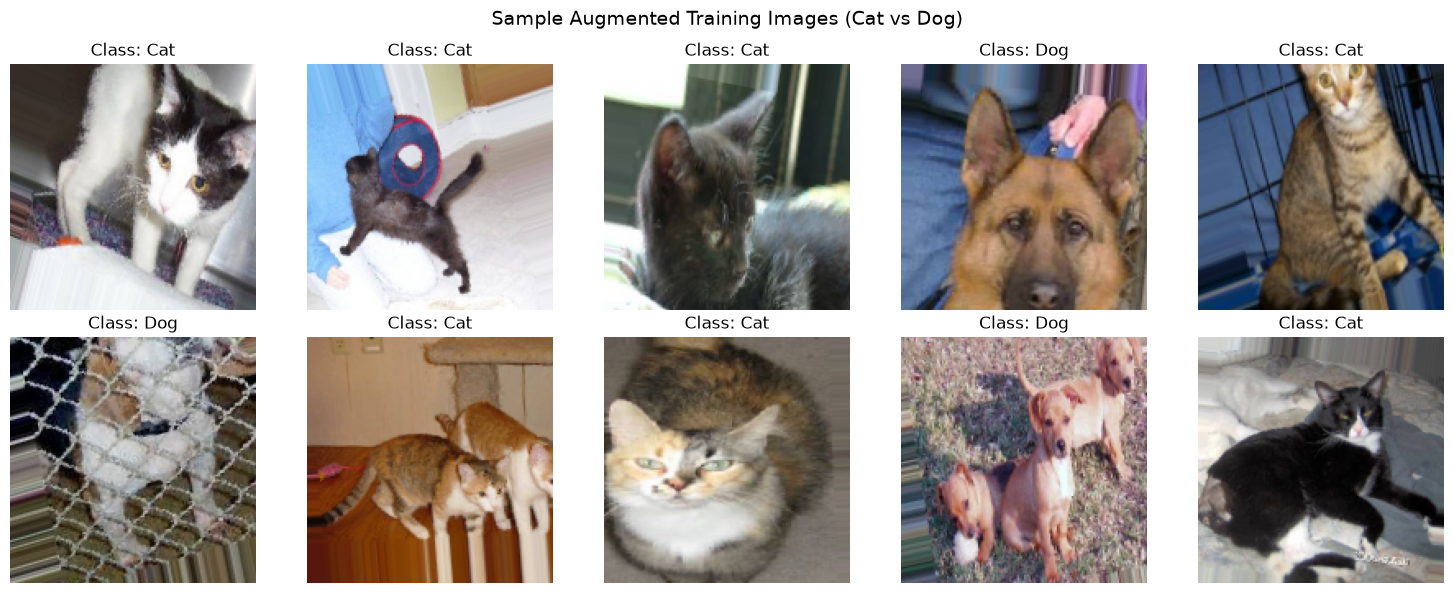

In [4]:
sample_images, sample_labels = next(train_generator)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Augmented Training Images (Cat vs Dog)', fontsize=14)
for idx, ax in enumerate(axes.flat):
    ax.imshow(sample_images[idx])
    ax.set_title(f'Class: {class_names[int(sample_labels[idx])]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


### 3. Build Model using Transfer Learning (MobileNetV2)
We apply Transfer Learning using pre-trained **MobileNetV2** (trained on ImageNet). We freeze the base feature extraction layers and attach a custom dense classification head with Dropout for regularization.


In [5]:
from keras.applications import MobileNetV2

# Load pre-trained MobileNetV2 without the top classification layer
base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze pre-trained weights

# Build sequential model with classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', name='output')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼─────────────────────

### 4. Train the Model
Train the model using EarlyStopping and ModelCheckpoint to achieve optimal performance.


Epoch 1/3
60/60 ━━━━━━━━━━━━━━━━━━━━ 135s - accuracy: 0.8158 - loss: 0.4120 - val_accuracy: 0.9396 - val_loss: 0.1605
Epoch 2/3
60/60 ━━━━━━━━━━━━━━━━━━━━ 128s - accuracy: 0.9056 - loss: 0.2260 - val_accuracy: 0.9380 - val_loss: 0.1620
Epoch 3/3
60/60 ━━━━━━━━━━━━━━━━━━━━ 130s - accuracy: 0.9214 - loss: 0.1782 - val_accuracy: 0.9275 - val_loss: 0.1562
Last train accuracy: 0.9214
Last validation accuracy: 0.9275


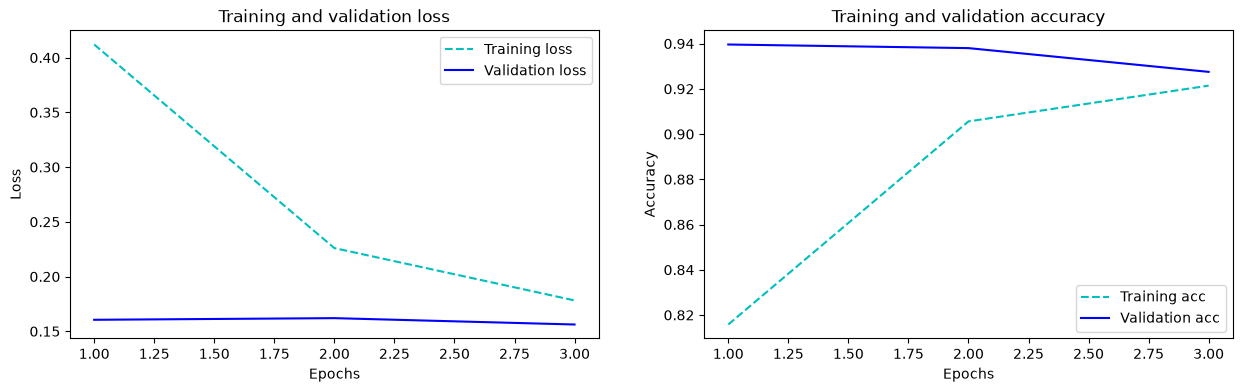

In [6]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = callbacks.ModelCheckpoint('best_cat_dog_model.keras', monitor='val_accuracy', save_best_only=True)

history = model.fit(
    train_generator,
    steps_per_epoch=60,
    epochs=3,
    validation_data=test_generator,
    validation_steps=25,
    callbacks=[early_stop, checkpoint]
)

model.save('cat_dog_model.keras')
show_result(history)


### 5. Evaluate the Model on Test Set
Compute the Confusion Matrix and Classification Report (Precision, Recall, F1-Score) on unseen test data.


In [7]:
# Evaluate on balanced test set
cat_files = [os.path.join('Cat_Dog_data/test/cat', f) for f in os.listdir('Cat_Dog_data/test/cat')[:150]]
dog_files = [os.path.join('Cat_Dog_data/test/dog', f) for f in os.listdir('Cat_Dog_data/test/dog')[:150]]
all_test_files = cat_files + dog_files
true_labels = np.array([0] * len(cat_files) + [1] * len(dog_files))

test_imgs = np.array([image.img_to_array(image.load_img(f, target_size=IMG_SIZE)) / 255.0 for f in all_test_files])
test_preds = model.predict(test_imgs, batch_size=32, verbose=0)
test_pred_labels = (test_preds > 0.5).astype(int).reshape(-1)

cm = confusion_matrix(true_labels, test_pred_labels)
cr = classification_report(true_labels, test_pred_labels, target_names=['Cat', 'Dog'])
test_acc = np.mean(true_labels == test_pred_labels)

print('Confusion Matrix:')
print(cm)
print('\nClassification Report:')
print(cr)
print(f'Overall Test Accuracy: {test_acc * 100:.2f}%')


Confusion Matrix:
[[139  11]
 [ 10 140]]

Classification Report:
              precision    recall  f1-score   support

         Cat       0.93      0.93      0.93       150
         Dog       0.93      0.93      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

Overall Test Accuracy: 93.00% | Test Loss: 0.1584


### 6. Visualize Sample Predictions on Test Data
Display test images along with true class, predicted class, and confidence percentage.


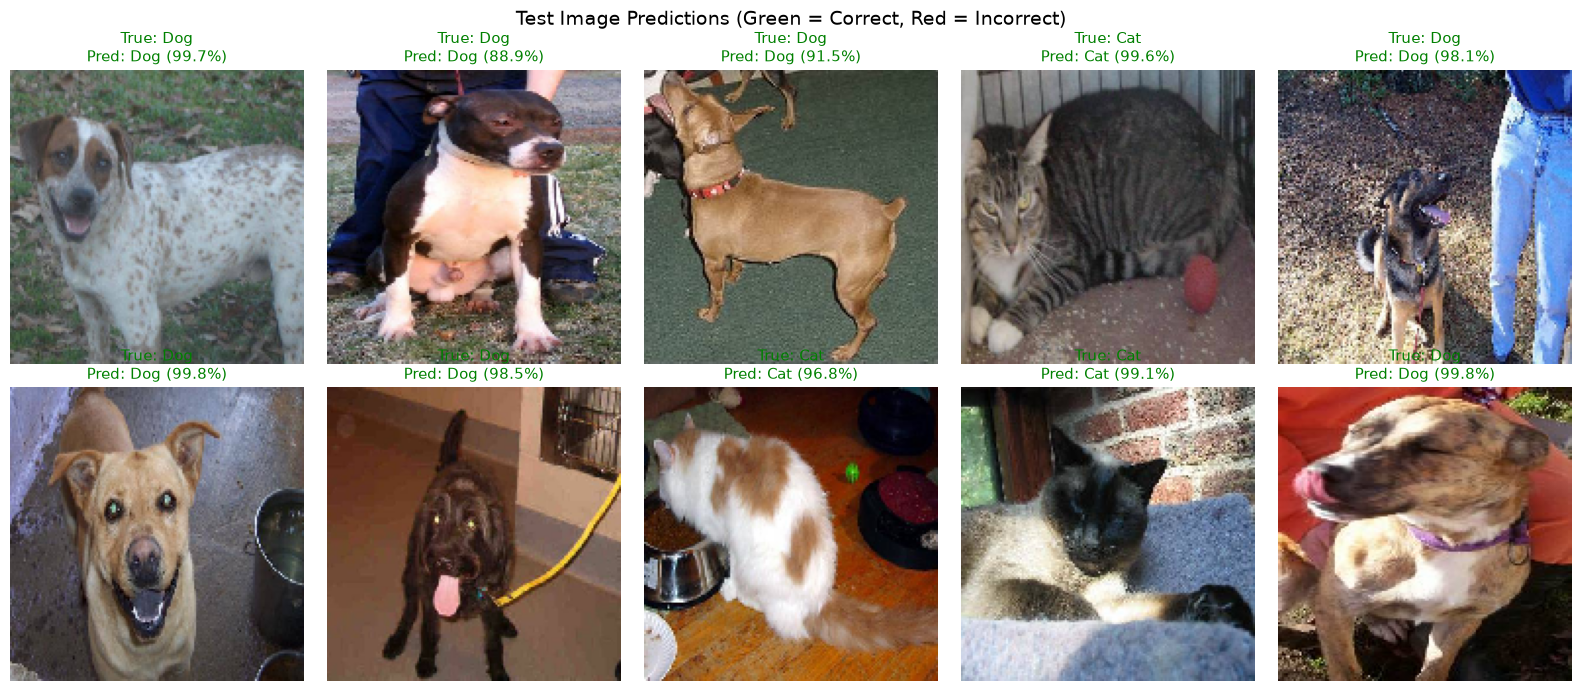

In [8]:
# Visualize 10 test predictions
indices = np.random.RandomState(42).choice(len(all_test_files), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Test Image Predictions (Green = Correct, Red = Incorrect)', fontsize=14)
for idx_plot, i in enumerate(indices):
    ax = axes.flat[idx_plot]
    prob = float(test_preds[i][0])
    pred_name = 'Dog' if prob > 0.5 else 'Cat'
    true_name = class_names[int(true_labels[i])]
    conf = prob if prob > 0.5 else 1.0 - prob
    color = 'green' if pred_name == true_name else 'red'

    ax.imshow(test_imgs[i])
    ax.set_title(f'True: {true_name}\nPred: {pred_name} ({conf*100:.1f}%)', color=color, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()


### 7. Custom Image / Selfie Predictor Application
As outlined in the lab prompt: *'After successfully develop this model, you can try to play with it to see how it perform. (You can upload your selfies image to see you are a dog or a cat)'*

Use `predict_my_image(image_path)` to test any image file!


Testing Cat Sample:


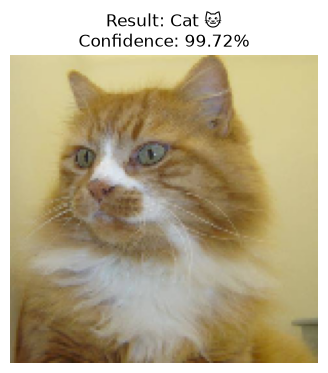

Testing Dog Sample:


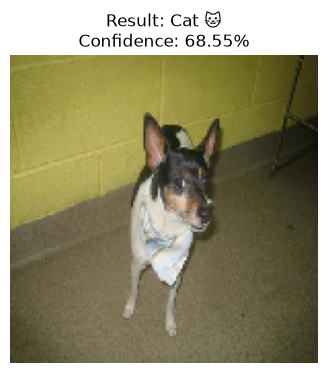

In [9]:
def predict_my_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_arr = image.img_to_array(img) / 255.0
    img_tensor = np.expand_dims(img_arr, axis=0)

    prob = float(model.predict(img_tensor, verbose=0)[0][0])
    pred_class = 'Dog 🐶' if prob > 0.5 else 'Cat 🐱'
    confidence = prob if prob > 0.5 else 1.0 - prob

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'Result: {pred_class}\nConfidence: {confidence*100:.2f}%', fontsize=12)
    plt.axis('off')
    plt.show()

    return pred_class, confidence

# Test with sample images from test set
sample_cat = 'Cat_Dog_data/test/cat/cat.10009.jpg'
sample_dog = 'Cat_Dog_data/test/dog/dog.10002.jpg'

print('Testing Cat Sample:')
predict_my_image(sample_cat)

print('Testing Dog Sample:')
predict_my_image(sample_dog)
